# Análisis del Proyecto Final: Navegación Autónoma con A* en Webots

**Curso:** ICI 4150 — Robótica y Sistemas Autónomos  **Semestre:** 2026-01  **Línea:** Línea A — Planificación de rutas con A* sobre grilla de ocupación  
Este notebook analiza las corridas experimentales del robot e-puck en los escenarios simple y complejo. Se calculan métricas de desempeño, se comparan las rutas planificadas con las trayectorias ejecutadas y se evalúan el comportamiento del filtro de Kalman y el control de velocidades.

---

## 1. Objetivos del análisis

1. Cuantificar el desempeño del robot en cada escenario (tiempo, distancia, error final).
2. Comparar visualmente la ruta planificada por A* con la trayectoria real medida por odometría.
3. Evaluar la estabilidad de las lecturas de distancia frontal y la efectividad del filtro de Kalman.
4. Analizar las velocidades de rueda y la evolución temporal de la navegación.
5. Extraer conclusiones y recomendaciones para el informe final.

In [1]:
import os
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Rutas a los datos
BASE_DIR = Path('../Lab_Final')  # Ajusta si corres el notebook desde otra ubicación

RUNS = {
    'Simple': {
        'log': BASE_DIR / 'datos_kalman_ruta_simple.csv',
        'route': BASE_DIR / 'datos_ruta_ruta_2_simple.csv',
        'goal': (0.375, -0.325),
        'bounds': (-0.5, 0.5, -0.5, 0.5),
    },
    'Compleja (ruta 1)': {
        'log': BASE_DIR / 'datos_kalman_ruta_1_compleja.csv',
        'route': BASE_DIR / 'datos_ruta_ruta_1_compleja.csv',
        'goal': (1.375, 1.375),
        'bounds': (-1.5, 1.5, -1.5, 1.5),
    },
    'Compleja (ruta 2)': {
        'log': BASE_DIR / 'datos_kalman_ruta_2_compleja.csv',
        'route': BASE_DIR / 'datos_ruta_ruta_2_compleja.csv',
        'goal': (1.375, 1.375),
        'bounds': (-1.5, 1.5, -1.5, 1.5),
    },
}

print('Rutas configuradas:')
for name, cfg in RUNS.items():
    print(f"  {name}: log={cfg['log'].exists()}, route={cfg['route'].exists()}")

Rutas configuradas:
  Simple: log=True, route=True
  Compleja (ruta 1): log=True, route=True
  Compleja (ruta 2): log=True, route=True


## 3. Funciones auxiliares

In [2]:
def read_metadata(path):
    """Lee los comentarios iniciales de un CSV como diccionario."""
    meta = {}
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            if not line.startswith('#'):
                break
            if ':' in line:
                key, _, value = line[2:].partition(':')
                meta[key.strip()] = value.strip()
    return meta

def read_log(path):
    """Carga el CSV de trayectoria real ignorando las líneas de metadata."""
    df = pd.read_csv(path, comment='#')
    # Convertir columnas numéricas
    numeric_cols = [c for c in df.columns if c not in ['phase', 'state', 'turn_dir']]
    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
    return df

def read_route(path):
    """Carga la ruta planificada."""
    return pd.read_csv(path)

def path_length(xs, ys):
    """Longitud de una polilínea."""
    return float(np.sum(np.hypot(np.diff(xs), np.diff(ys))))

def compute_run_metrics(df, route_df, goal):
    """Calcula métricas de una corrida."""
    # Tiempo total hasta meta
    t_total = df['time_s'].max() - df['time_s'].min()

    # Distancia recorrida (odometría integrada por segmentos)
    dx = df['x_m'].diff().fillna(0)
    dy = df['y_m'].diff().fillna(0)
    dist_traj = float(np.sum(np.hypot(dx, dy)))

    # Velocidad lineal estimada
    dt = df['time_s'].diff().fillna(df['Ts_s'].iloc[0] if 'Ts_s' in df.columns else 0.032)
    v = np.hypot(dx, dy) / dt
    v_mean = float(v.mean())
    v_std = float(v.std())

    # Longitud de ruta planificada
    dist_route = path_length(route_df['x_m'].values, route_df['y_m'].values)

    # Error de posición final respecto a la meta
    x_f, y_f = df['x_m'].iloc[-1], df['y_m'].iloc[-1]
    error_final = math.hypot(x_f - goal[0], y_f - goal[1])

    # Waypoints totales y último alcanzado
    waypoints_total = int(df['waypoints_total'].iloc[0]) if 'waypoints_total' in df.columns else len(route_df)
    waypoint_final = int(df['waypoint_idx'].iloc[-1])

    # Capa reactiva: contar estados distintos a WAYPOINT_FOLLOW/GOAL_REACHED
    reactive_states = df[~df['state'].isin(['WAYPOINT_FOLLOW', 'GOAL_REACHED'])]
    reactive_count = len(reactive_states)

    # Detecciones cercanas: lectura frontal cruda por debajo de 10 cm
    close_calls = int((df['front_raw_m'] < 0.10).sum())

    # Error máximo de trayectoria respecto a la ruta planificada (distancia mínima a la polilínea)
    traj_points = df[['x_m', 'y_m']].values
    route_points = route_df[['x_m', 'y_m']].values
    dists = []
    for p in traj_points[::max(1, len(traj_points)//500)]:  # muestrear para velocidad
        d = np.min(np.hypot(route_points[:, 0] - p[0], route_points[:, 1] - p[1]))
        dists.append(d)
    max_deviation = float(np.max(dists)) if dists else np.nan
    mean_deviation = float(np.mean(dists)) if dists else np.nan

    return {
        'Tiempo total (s)': t_total,
        'Distancia planificada (m)': dist_route,
        'Distancia ejecutada (m)': dist_traj,
        'Diferencia distancia (m)': dist_traj - dist_route,
        'Velocidad media (m/s)': v_mean,
        'Desv. vel. media (m/s)': v_std,
        'Error posición final (m)': error_final,
        'Waypoints totales': waypoints_total,
        'Waypoint final': waypoint_final,
        'Activaciones reactivas': reactive_count,
        'Casi colisiones (<10cm)': close_calls,
        'Desviación media (m)': mean_deviation,
        'Desviación máxima (m)': max_deviation,
    }

print('Funciones cargadas correctamente.')

Funciones cargadas correctamente.


## 4. Carga de datos

In [3]:
data = {}
metadata = {}

for name, cfg in RUNS.items():
    print(f"Cargando {name}...")
    log_df = read_log(cfg['log'])
    route_df = read_route(cfg['route'])
    meta = read_metadata(cfg['log'])
    data[name] = {'log': log_df, 'route': route_df, 'goal': cfg['goal']}
    metadata[name] = meta
    print(f"  Log: {len(log_df)} filas | Ruta: {len(route_df)} waypoints")

print('\nCarga completada.')

Cargando Simple...
  Log: 8294 filas | Ruta: 27 waypoints
Cargando Compleja (ruta 1)...


  Log: 38339 filas | Ruta: 109 waypoints
Cargando Compleja (ruta 2)...
  Log: 20685 filas | Ruta: 91 waypoints

Carga completada.


## 5. Tabla resumen de métricas

In [4]:
metrics = []
for name, d in data.items():
    m = compute_run_metrics(d['log'], d['route'], d['goal'])
    m['Escenario'] = name
    metrics.append(m)

metrics_df = pd.DataFrame(metrics).set_index('Escenario')
display(metrics_df.round(3))

,Tiempo total (s),Distancia planificada (m),Distancia ejecutada (m),Diferencia distancia (m),Velocidad media (m/s),Desv. vel. media (m/s),Error posición final (m),Waypoints totales,Waypoint final,Activaciones reactivas,Casi colisiones (<10cm),Desviación media (m),Desviación máxima (m)
Escenario,,,,,,,,,,,,,
Simple,265.376,1.466,1.564,0.098,0.006,0.007,0.05,27,27,0,0,0.025,0.04
Compleja (ruta 1),613.408,5.566,5.839,0.274,0.010,0.008,0.05,109,109,0,0,0.014,0.04
Compleja (ruta 2),330.944,4.914,4.908,-0.006,0.015,0.006,0.05,91,91,0,0,0.015,0.04


### Interpretación preliminar

- **Tiempo total:** el escenario simple se resuelve en menos tiempo; el complejo puede variar según la ruta tomada.
- **Distancia ejecutada vs planificada:** una diferencia pequeña indica buen seguimiento de la ruta A*.
- **Error final:** valores menores al `goal_tolerance_m` (5 cm) significan que el robot declaró meta alcanzada correctamente.
- **Casi colisiones:** lecturas frontales menores a 10 cm. Si son cero o muy pocas, la navegación fue segura.

## 6. Visualización: ruta planificada vs trayectoria real

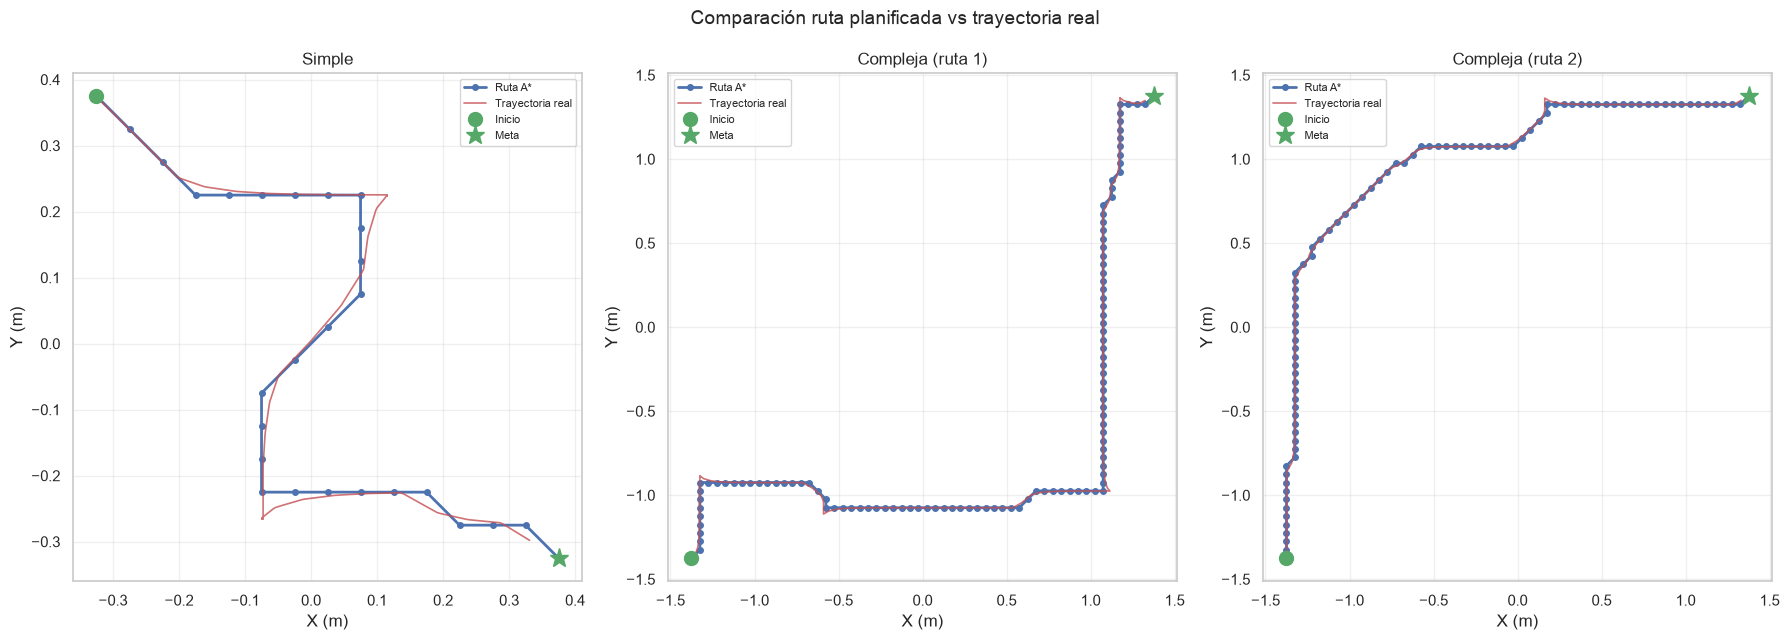

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (name, d) in zip(axes, data.items()):
    log = d['log']
    route = d['route']
    goal = d['goal']

    # Ruta planificada
    ax.plot(route['x_m'], route['y_m'], 'b-o', linewidth=2, markersize=4, label='Ruta A*', zorder=3)

    # Trayectoria real (submuestreo para claridad)
    step = max(1, len(log) // 1000)
    ax.plot(log['x_m'].iloc[::step], log['y_m'].iloc[::step], 'r-', linewidth=1.2, alpha=0.8, label='Trayectoria real', zorder=4)

    # Inicio y meta
    ax.plot(log['x_m'].iloc[0], log['y_m'].iloc[0], 'go', markersize=10, label='Inicio', zorder=5)
    ax.plot(goal[0], goal[1], 'g*', markersize=14, label='Meta', zorder=5)

    ax.set_title(name)
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=8)

plt.suptitle('Comparación ruta planificada vs trayectoria real', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Evolución temporal de la navegación

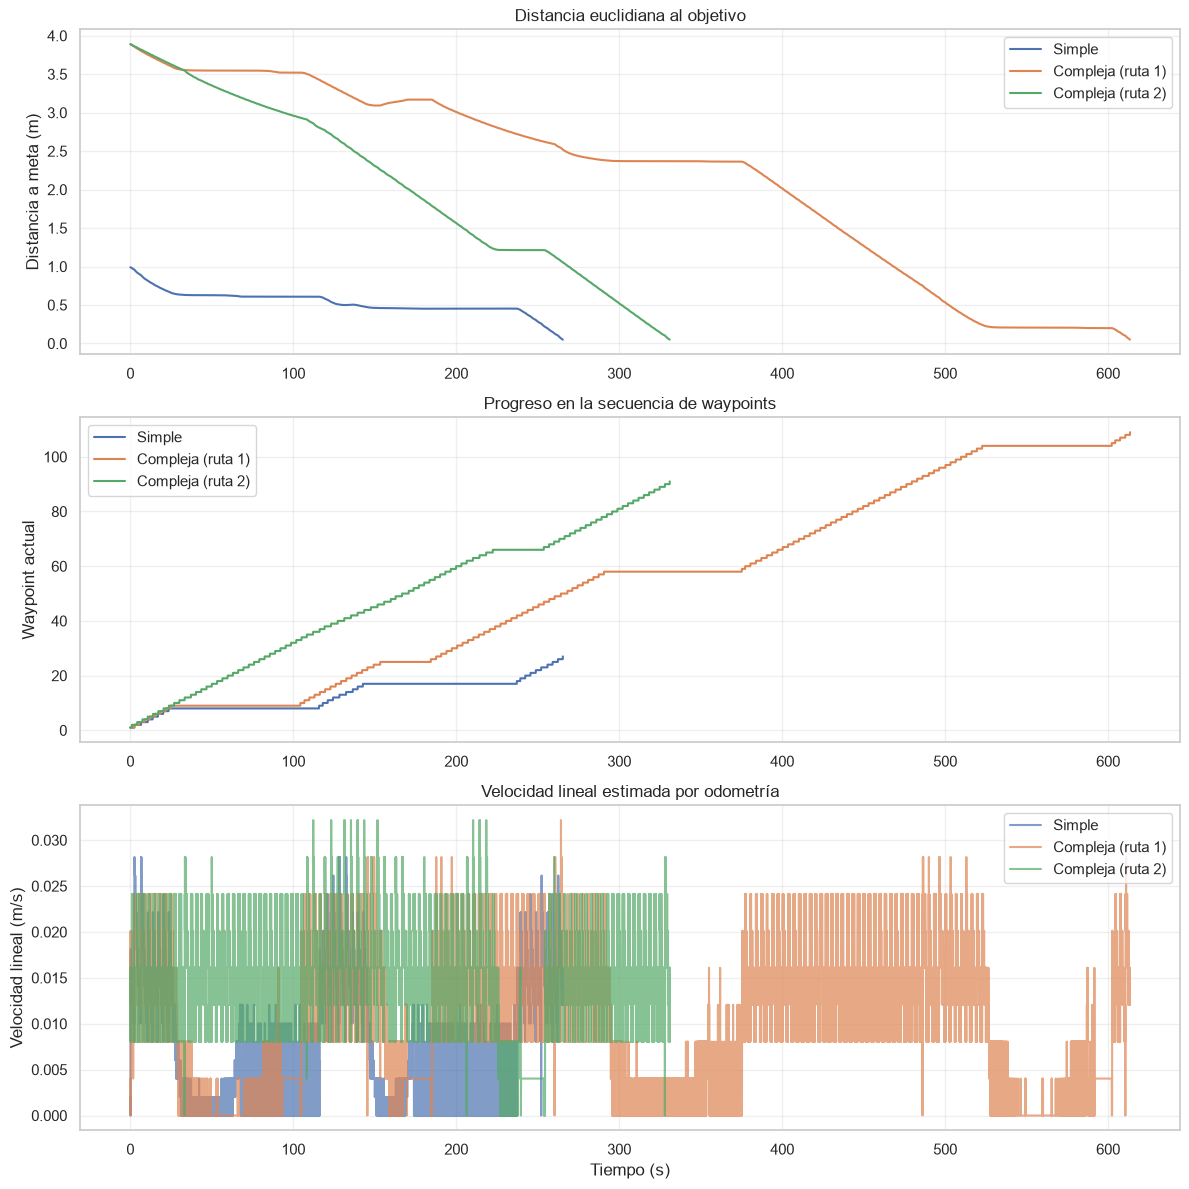

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

for name, d in data.items():
    log = d['log']

    # Distancia a la meta
    axes[0].plot(log['time_s'], log['dist_to_goal_m'], label=name)

    # Índice de waypoint actual
    axes[1].plot(log['time_s'], log['waypoint_idx'], label=name)

    # Velocidad lineal instantánea
    dt = log['time_s'].diff().fillna(log['Ts_s'].iloc[0] if 'Ts_s' in log.columns else 0.032)
    vx = log['x_m'].diff() / dt
    vy = log['y_m'].diff() / dt
    v = np.hypot(vx, vy)
    axes[2].plot(log['time_s'], v, alpha=0.7, label=name)

axes[0].set_ylabel('Distancia a meta (m)')
axes[0].set_title('Distancia euclidiana al objetivo')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_ylabel('Waypoint actual')
axes[1].set_title('Progreso en la secuencia de waypoints')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].set_ylabel('Velocidad lineal (m/s)')
axes[2].set_xlabel('Tiempo (s)')
axes[2].set_title('Velocidad lineal estimada por odometría')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Análisis de sensores y filtrado de Kalman

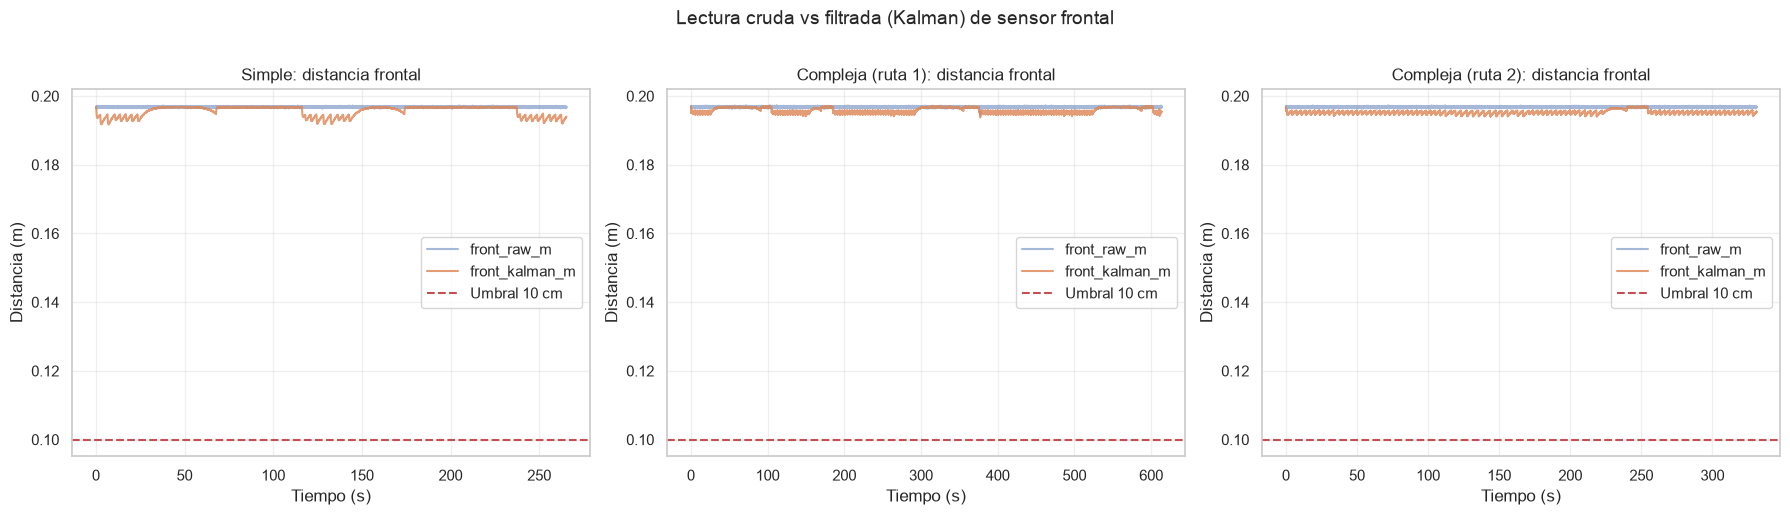

,Media raw (m),Media Kalman (m),Std raw (m),Std Kalman (m),Mín raw (m),Mín Kalman (m)
Escenario,,,,,,
Simple,0.1968,0.1956,0.0001,0.0015,0.1963,0.1918
Compleja (ruta 1),0.1968,0.1958,0.0001,0.0008,0.1947,0.1938
Compleja (ruta 2),0.1968,0.1953,0.0001,0.0005,0.1962,0.1940


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, d) in zip(axes, data.items()):
    log = d['log']
    t = log['time_s']
    ax.plot(t, log['front_raw_m'], alpha=0.5, label='front_raw_m')
    ax.plot(t, log['front_kalman_m'], alpha=0.8, label='front_kalman_m')
    ax.axhline(0.10, color='r', linestyle='--', label='Umbral 10 cm')
    ax.set_title(f'{name}: distancia frontal')
    ax.set_xlabel('Tiempo (s)')
    ax.set_ylabel('Distancia (m)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Lectura cruda vs filtrada (Kalman) de sensor frontal', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Tabla de estabilidad
sensor_stats = []
for name, d in data.items():
    log = d['log']
    sensor_stats.append({
        'Escenario': name,
        'Media raw (m)': log['front_raw_m'].mean(),
        'Media Kalman (m)': log['front_kalman_m'].mean(),
        'Std raw (m)': log['front_raw_m'].std(),
        'Std Kalman (m)': log['front_kalman_m'].std(),
        'Mín raw (m)': log['front_raw_m'].min(),
        'Mín Kalman (m)': log['front_kalman_m'].min(),
    })
display(pd.DataFrame(sensor_stats).set_index('Escenario').round(4))

### Interpretación del filtrado

- Si la desviación estándar del Kalman es menor que la de la señal cruda, el filtro está suavizando ruido.
- El valor mínimo indica la distancia más cercana a un obstáculo; si no baja de ~10 cm, el robot mantuvo margen de seguridad.

## 9. Comandos de velocidad de ruedas

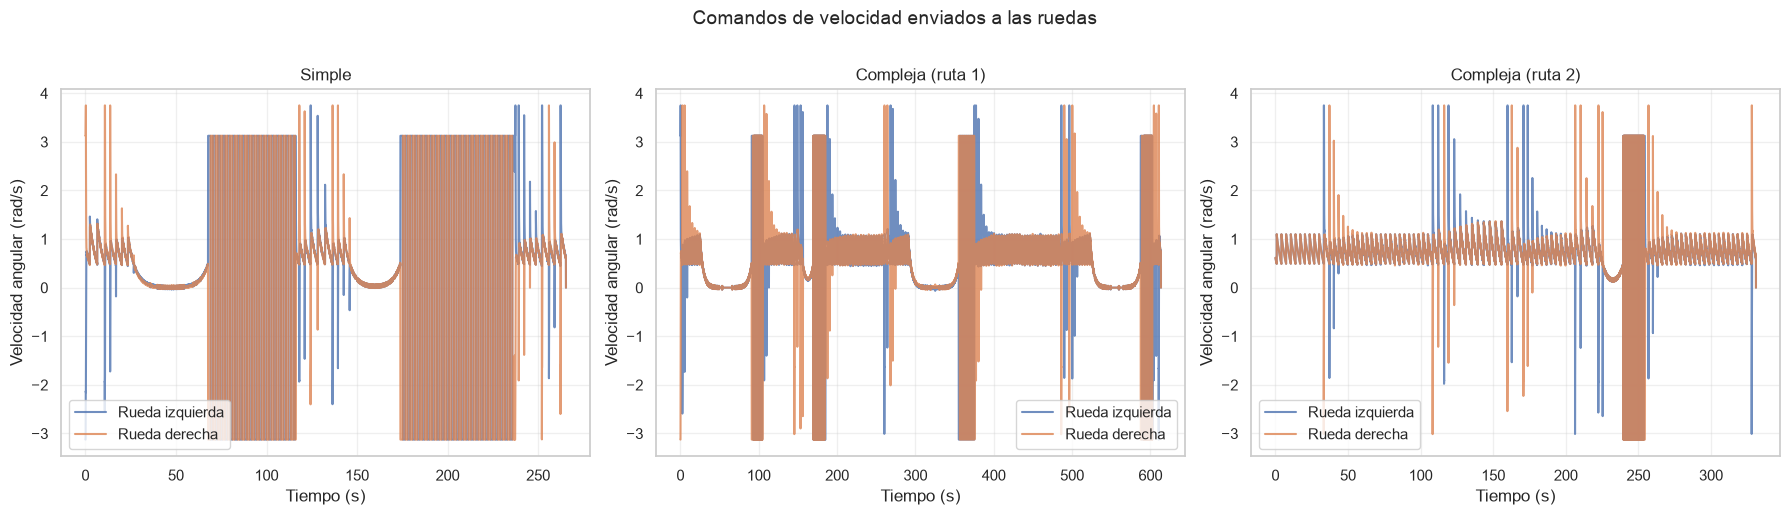

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, d) in zip(axes, data.items()):
    log = d['log']
    t = log['time_s']
    ax.plot(t, log['cmd_left_vel'], label='Rueda izquierda', alpha=0.8)
    ax.plot(t, log['cmd_right_vel'], label='Rueda derecha', alpha=0.8)
    ax.set_title(name)
    ax.set_xlabel('Tiempo (s)')
    ax.set_ylabel('Velocidad angular (rad/s)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Comandos de velocidad enviados a las ruedas', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 10. Comparación cuantitativa entre escenarios

/tmp/ipykernel_46792/4013620087.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_plot, x='Escenario', y=col, ax=ax, palette='viridis')
/tmp/ipykernel_46792/4013620087.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_plot, x='Escenario', y=col, ax=ax, palette='viridis')
/tmp/ipykernel_46792/4013620087.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_plot, x='Escenario', y=col, ax=ax, palette='viridis')
/tmp/ipykernel_46792/4013620087.py:17: FutureWarning: 

Passing `palette` without assigning

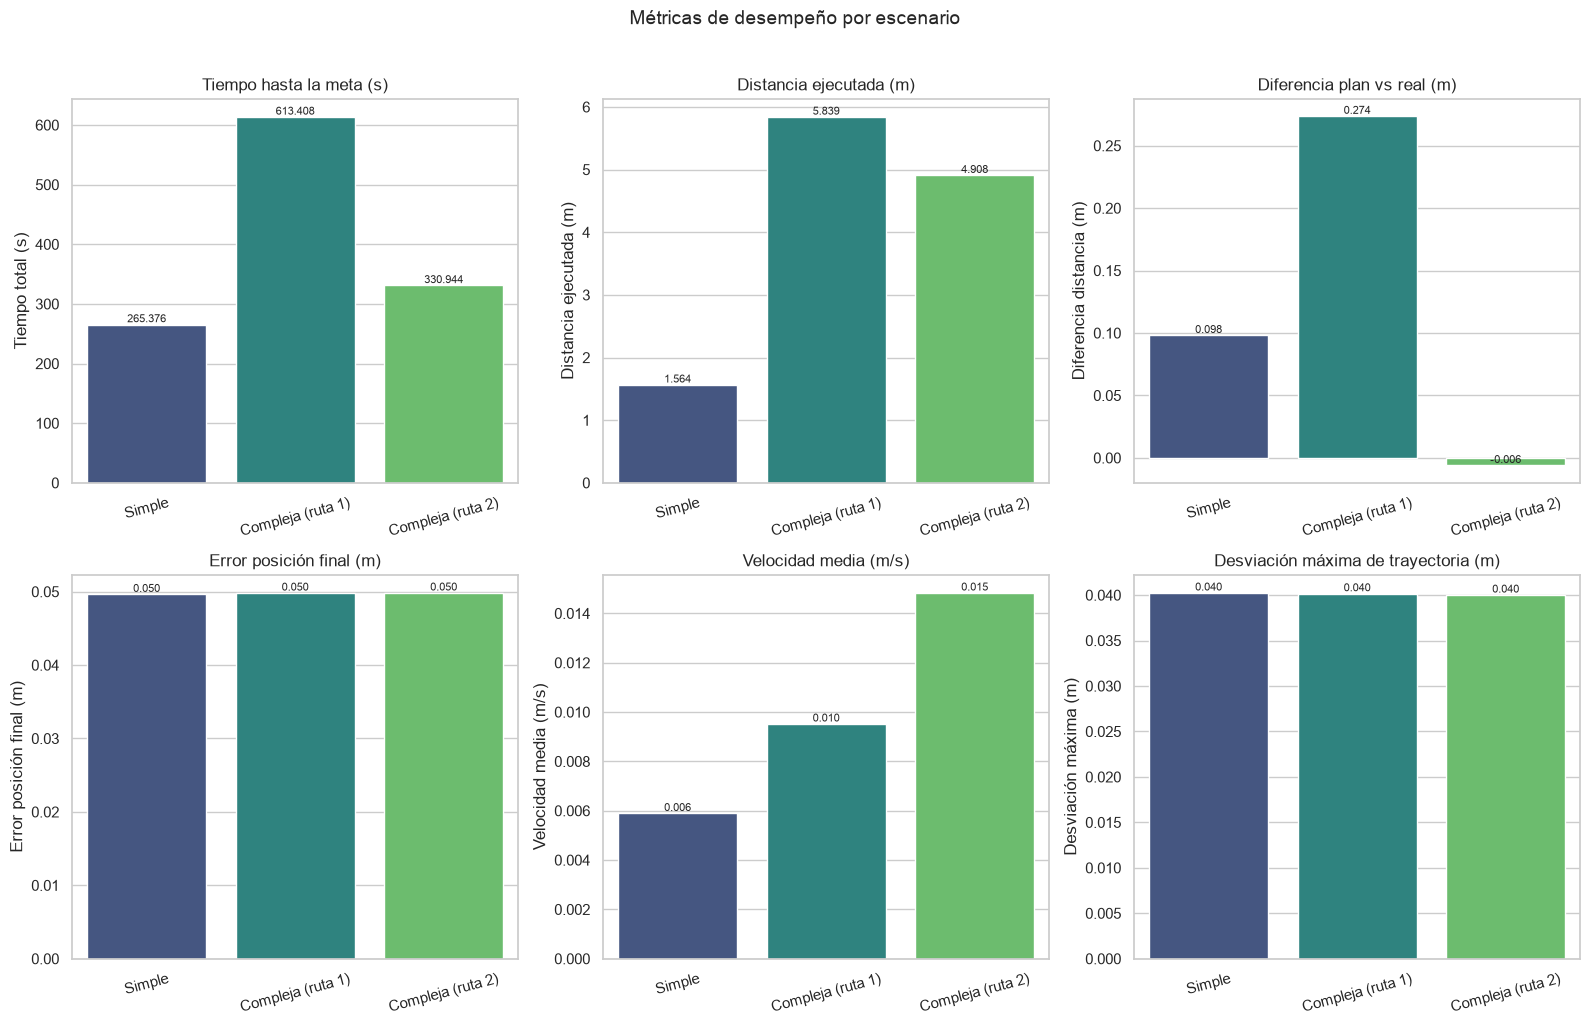

In [9]:
# Preparar datos para gráficos comparativos
metrics_plot = metrics_df.reset_index()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

cols = [
    ('Tiempo total (s)', 'Tiempo hasta la meta (s)'),
    ('Distancia ejecutada (m)', 'Distancia ejecutada (m)'),
    ('Diferencia distancia (m)', 'Diferencia plan vs real (m)'),
    ('Error posición final (m)', 'Error posición final (m)'),
    ('Velocidad media (m/s)', 'Velocidad media (m/s)'),
    ('Desviación máxima (m)', 'Desviación máxima de trayectoria (m)'),
]

for ax, (col, title) in zip(axes, cols):
    sns.barplot(data=metrics_plot, x='Escenario', y=col, ax=ax, palette='viridis')
    ax.set_title(title)
    ax.set_ylabel(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.3f}",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.suptitle('Métricas de desempeño por escenario', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 11. Análisis de la odometría y error acumulado

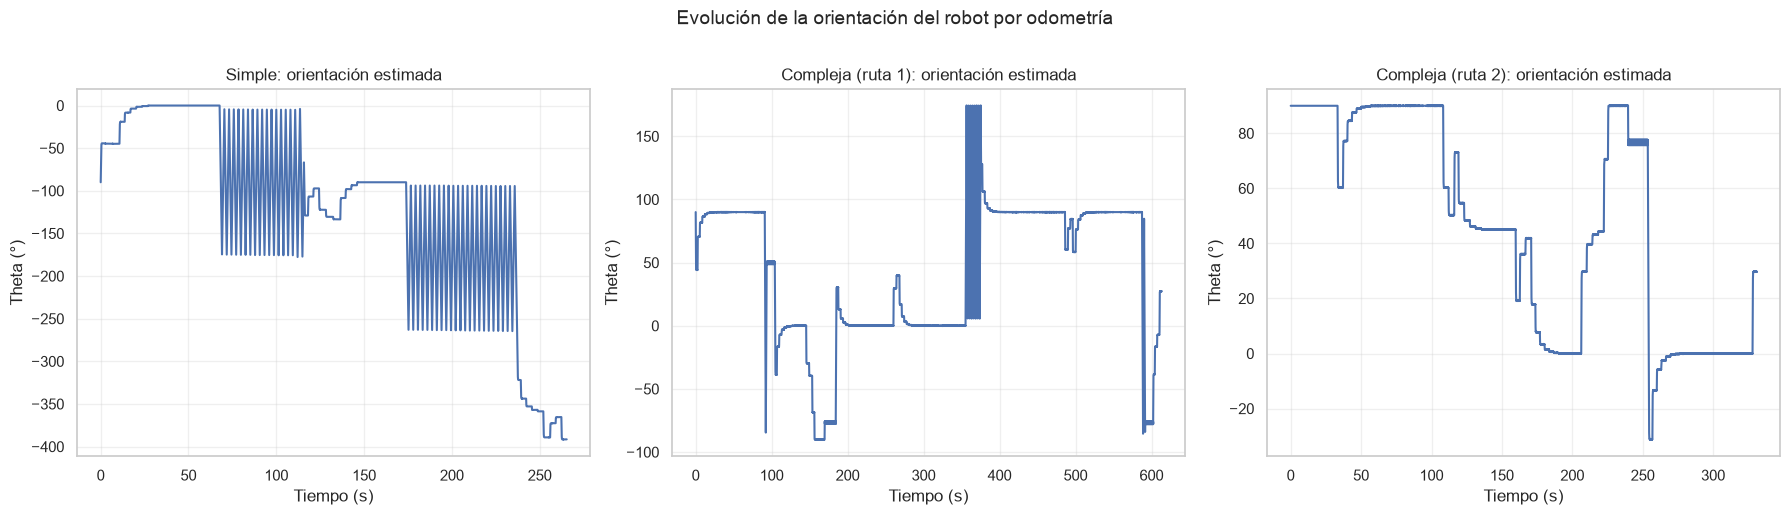

,Delta theta total (°),Delta s total (m),Giros netos (°)
Escenario,,,
Simple,14732.69,1.50,-301.49
Compleja (ruta 1),9792.40,5.65,-62.69
Compleja (ruta 2),2935.06,4.85,-60.25


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, d) in zip(axes, data.items()):
    log = d['log']
    # Error acumulado de orientación: theta desenrollado
    theta = log['theta_rad'].values
    theta_unwrapped = np.unwrap(theta)
    ax.plot(log['time_s'], np.degrees(theta_unwrapped))
    ax.set_title(f'{name}: orientación estimada')
    ax.set_xlabel('Tiempo (s)')
    ax.set_ylabel('Theta (°)')
    ax.grid(True, alpha=0.3)

plt.suptitle('Evolución de la orientación del robot por odometría', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Estadísticas de odometría
odo_stats = []
for name, d in data.items():
    log = d['log']
    odo_stats.append({
        'Escenario': name,
        'Delta theta total (°)': np.degrees(np.sum(np.abs(log['delta_theta_rad'].fillna(0)))),
        'Delta s total (m)': log['delta_s_m'].sum(),
        'Giros netos (°)': np.degrees(np.unwrap(log['theta_rad'].values)[-1] - np.unwrap(log['theta_rad'].values)[0]),
    })
display(pd.DataFrame(odo_stats).set_index('Escenario').round(2))

## 12. Histograma de distancia frontal (seguridad de navegación)

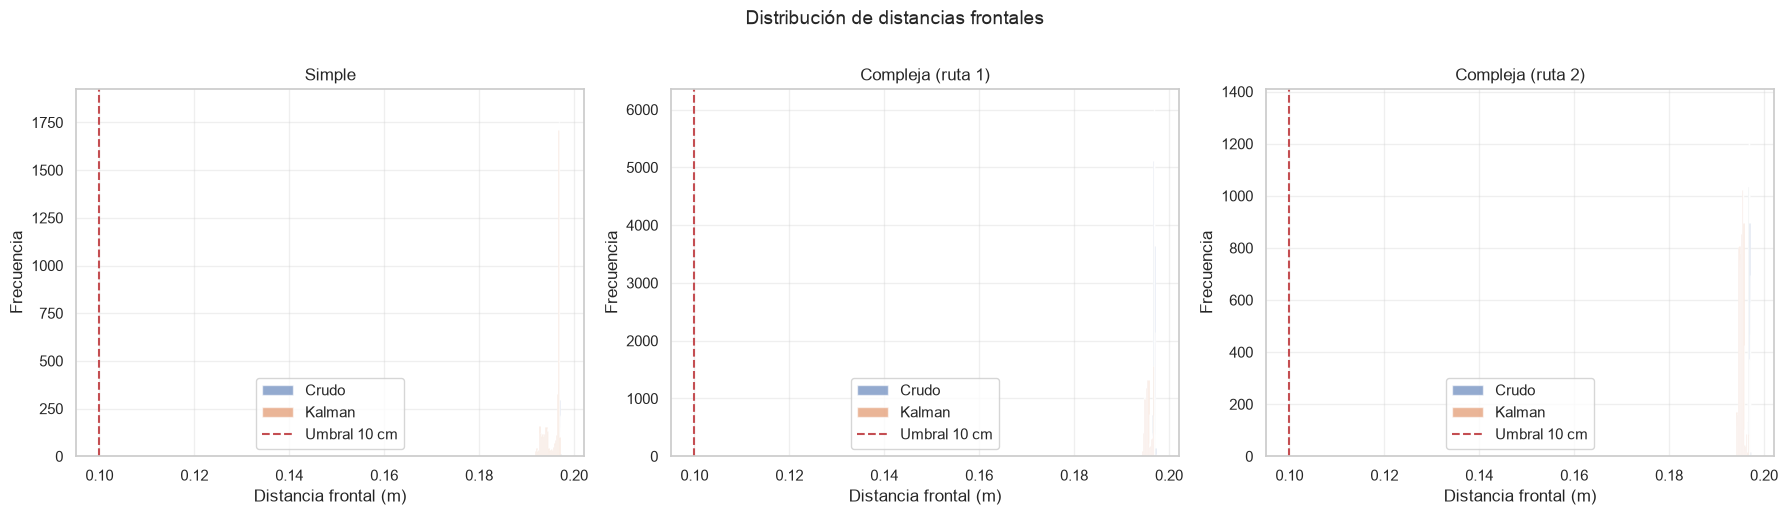

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, d) in zip(axes, data.items()):
    log = d['log']
    ax.hist(log['front_raw_m'], bins=50, alpha=0.6, label='Crudo')
    ax.hist(log['front_kalman_m'], bins=50, alpha=0.6, label='Kalman')
    ax.axvline(0.10, color='r', linestyle='--', label='Umbral 10 cm')
    ax.set_title(name)
    ax.set_xlabel('Distancia frontal (m)')
    ax.set_ylabel('Frecuencia')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Distribución de distancias frontales', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 13. Conclusiones y recomendaciones

A continuación se presentan las conclusiones derivadas de las métricas y gráficos anteriores. Puedes completarlas con observaciones propias de las simulaciones.

### Resultados esperados a destacar

1. **Eficiencia de la planificación:** la distancia ejecutada debe ser cercana a la planificada por A*. Diferencias grandes pueden deberse a desvíos, replanificaciones o giros en el lugar.
2. **Llegada a la meta:** el error de posición final debe ser menor o igual a 5 cm (`goal_tolerance_m`), lo cual indica éxito en la navegación.
3. **Seguridad:** lecturas frontales que nunca bajan de ~10 cm indican que el robot mantuvo distancia de los obstáculos y no requirió activar la capa reactiva de emergencia.
4. **Filtrado:** la señal filtrada por Kalman debe mostrar menor variabilidad que la cruda, evidenciando estabilidad en la percepción.
5. **Odometría:** el error acumulado en trayectorias largas puede notarse como una trayectoria ejecutada ligeramente desplazada respecto a la planificada.

### Limitaciones observables

- En escenarios complejos, el robot puede tardar más debido a giros en el lugar y pasillos estrechos.
- La odometría basada solo en encoders acumula error en giros prolongados.
- La velocidad media baja indica que el robot pasa mucho tiempo alineándose o girando.

### Posibles mejoras

- **Giróscopo:** habilitar `USE_GYRO = True` en `Ruedas.py` para reducir el error de orientación.
- **Suavizado de waypoints:** interpolar la ruta A* para evitar paradas en cada esquina.
- **Controlador de seguimiento:** probar controlador PID puro pursuit en lugar de giro-en-el-lugar.
- **Margen de inflación:** ajustar `GRID_INFLATION_M` si algunos pasillos quedan bloqueados.

## 14. Exportar métricas para el README

Ejecuta esta celda para generar un archivo `metricas_resumen.csv` que puedas incorporar directamente al informe final o al `README.md`.

In [12]:
output_csv = Path('metricas_resumen.csv')
metrics_df.round(4).to_csv(output_csv)
print(f'Métricas exportadas a: {output_csv.resolve()}')
display(metrics_df.round(4))

Métricas exportadas a: /mnt/pool/Documentos/Universidad/Robotica/Lab/GitLab/Robotica_PUCV/laboratorio_final/Analisis/metricas_resumen.csv


,Tiempo total (s),Distancia planificada (m),Distancia ejecutada (m),Diferencia distancia (m),Velocidad media (m/s),Desv. vel. media (m/s),Error posición final (m),Waypoints totales,Waypoint final,Activaciones reactivas,Casi colisiones (<10cm),Desviación media (m),Desviación máxima (m)
Escenario,,,,,,,,,,,,,
Simple,265.376,1.4657,1.5638,0.0981,0.0059,0.0073,0.0496,27,27,0,0,0.0246,0.0402
Compleja (ruta 1),613.408,5.5657,5.8393,0.2736,0.0095,0.0076,0.0498,109,109,0,0,0.0138,0.0402
Compleja (ruta 2),330.944,4.9142,4.9082,-0.0060,0.0148,0.0057,0.0498,91,91,0,0,0.0154,0.0400
